In [4]:
# ============================================================
# AI Innovators Lab: Heart Disease Risk Prediction
# Goal: Train an AI model that predicts heart disease risk using
#       fictional/random patient examples.
#
# IMPORTANT:
# This project is for education only.
# It is NOT medical advice and should NOT be used for diagnosis.
#
# Dataset:
# UCI Heart Disease Dataset
# Link: https://archive.ics.uci.edu/dataset/45/heart+disease
#
# Model:
# Random Forest Classifier
# ============================================================

print("Welcome to the Heart Disease Prediction Project!")
print("Goal: Learn how AI can use health-related data to make predictions.")
print("Important: This is for education only, not medical advice.")


Welcome to the Heart Disease Prediction Project!
Goal: Learn how AI can use health-related data to make predictions.
Important: This is for education only, not medical advice.


In [5]:
# ============================================================
# Step 1: Import required libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [6]:
# ============================================================
# Step 2: Download the UCI Heart Disease dataset
# ============================================================

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
file_name = "processed_cleveland_heart_disease.csv"

response = requests.get(dataset_url)

with open(file_name, "wb") as file:
    file.write(response.content)

print("Dataset downloaded successfully!")


Dataset downloaded successfully!


In [7]:
# ============================================================
# Step 3: Load the dataset
#
# The dataset does not include column names, so we add them.
# ============================================================

columns = [
    "age",
    "sex",
    "chest_pain_type",
    "resting_blood_pressure",
    "cholesterol",
    "fasting_blood_sugar",
    "resting_ecg",
    "max_heart_rate",
    "exercise_angina",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

data = pd.read_csv(file_name, names=columns)

print("Dataset loaded successfully!")
print(data.head())



Dataset loaded successfully!
    age  sex  chest_pain_type  resting_blood_pressure  cholesterol  \
0  63.0  1.0              1.0                   145.0        233.0   
1  67.0  1.0              4.0                   160.0        286.0   
2  67.0  1.0              4.0                   120.0        229.0   
3  37.0  1.0              3.0                   130.0        250.0   
4  41.0  0.0              2.0                   130.0        204.0   

   fasting_blood_sugar  resting_ecg  max_heart_rate  exercise_angina  oldpeak  \
0                  1.0          2.0           150.0              0.0      2.3   
1                  0.0          2.0           108.0              1.0      1.5   
2                  0.0          2.0           129.0              1.0      2.6   
3                  0.0          0.0           187.0              0.0      3.5   
4                  0.0          2.0           172.0              0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    

In [8]:
# ============================================================
# Step 4: Clean the dataset
#
# Some missing values are marked with "?".
# We replace them with missing values and remove incomplete rows.
# ============================================================

data = data.replace("?", np.nan)
data = data.dropna()

# Convert all columns to numbers
for col in data.columns:
    data[col] = pd.to_numeric(data[col])

print("Dataset cleaned successfully!")
print("Number of rows after cleaning:", len(data))



Dataset cleaned successfully!
Number of rows after cleaning: 297


In [9]:
# ============================================================
# Step 5: Create simple labels
#
# In the original dataset:
# target = 0 means no heart disease
# target = 1, 2, 3, or 4 means presence of heart disease
#
# We convert it to:
# 0 = Lower Risk
# 1 = Higher Risk
# ============================================================

data["risk"] = data["target"].apply(lambda x: 0 if x == 0 else 1)

print("Risk labels created!")
print(data["risk"].value_counts())



Risk labels created!
risk
0    160
1    137
Name: count, dtype: int64


In [10]:
# ============================================================
# Step 6: Select easy-to-understand input features
#
# We focus on:
# - age
# - resting blood pressure
# - cholesterol
# - max heart rate
#
# These are easier for students to understand.
# ============================================================

X = data[[
    "age",
    "resting_blood_pressure",
    "cholesterol",
    "max_heart_rate"
]]

y = data["risk"]

print("Selected input features:")
print(X.head())



Selected input features:
    age  resting_blood_pressure  cholesterol  max_heart_rate
0  63.0                   145.0        233.0           150.0
1  67.0                   160.0        286.0           108.0
2  67.0                   120.0        229.0           129.0
3  37.0                   130.0        250.0           187.0
4  41.0                   130.0        204.0           172.0


In [11]:
# ============================================================
# Step 7: Split data into training and testing sets
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))



Training examples: 222
Testing examples: 75


In [12]:
# ============================================================
# Step 8: Build and train the Random Forest model
#
# Random Forest uses many decision trees and combines their answers.
# ============================================================

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")



Model training completed!


In [13]:
# ============================================================
# Step 9: Evaluate the model
# ============================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Lower Risk", "Higher Risk"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Model Accuracy: 76.0 %

Classification Report:
              precision    recall  f1-score   support

  Lower Risk       0.78      0.78      0.78        40
 Higher Risk       0.74      0.74      0.74        35

    accuracy                           0.76        75
   macro avg       0.76      0.76      0.76        75
weighted avg       0.76      0.76      0.76        75


Confusion Matrix:
[[31  9]
 [ 9 26]]


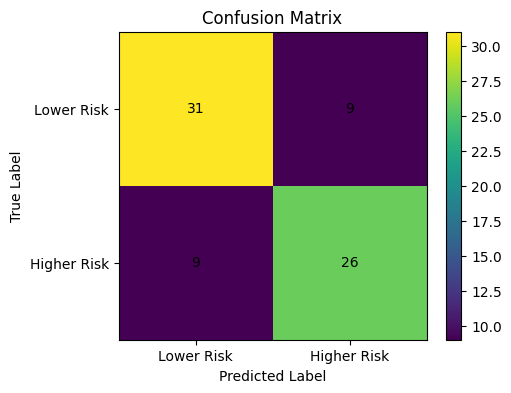

In [14]:
# ============================================================
# Step 10: Visualize confusion matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Lower Risk", "Higher Risk"])
plt.yticks([0, 1], ["Lower Risk", "Higher Risk"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()



Feature Importance:
                  Feature  Importance
3          max_heart_rate    0.373603
0                     age    0.280406
2             cholesterol    0.191266
1  resting_blood_pressure    0.154725


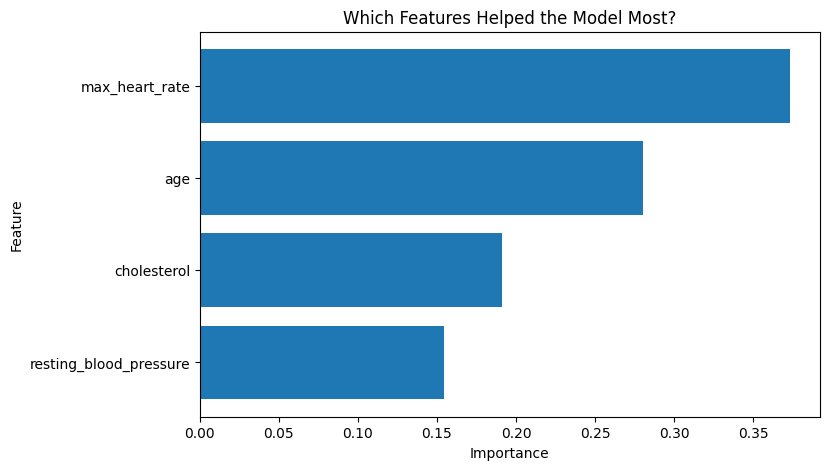

In [15]:
# ============================================================
# Step 11: Feature importance
#
# This shows which inputs were most useful to the model.
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Which Features Helped the Model Most?")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()



In [16]:
# ============================================================
# Step 12: Test fictional/random patient examples
#
# These are NOT real people.
# Students should not enter their own personal health information.
# ============================================================

fictional_patients = pd.DataFrame([
    {
        "age": 35,
        "resting_blood_pressure": 120,
        "cholesterol": 180,
        "max_heart_rate": 170
    },
    {
        "age": 55,
        "resting_blood_pressure": 145,
        "cholesterol": 250,
        "max_heart_rate": 135
    },
    {
        "age": 70,
        "resting_blood_pressure": 165,
        "cholesterol": 290,
        "max_heart_rate": 110
    }
])

fictional_predictions = model.predict(fictional_patients)
fictional_probabilities = model.predict_proba(fictional_patients)

print("Fictional Patient Predictions:\n")

for i in range(len(fictional_patients)):
    prediction = fictional_predictions[i]
    confidence = max(fictional_probabilities[i]) * 100

    label = "Higher Risk" if prediction == 1 else "Lower Risk"

    print("Fictional Patient", i + 1)
    print(fictional_patients.iloc[i])
    print("AI Prediction:", label)
    print("Confidence:", round(confidence, 2), "%")
    print("-" * 60)



Fictional Patient Predictions:

Fictional Patient 1
age                        35
resting_blood_pressure    120
cholesterol               180
max_heart_rate            170
Name: 0, dtype: int64
AI Prediction: Lower Risk
Confidence: 74.49 %
------------------------------------------------------------
Fictional Patient 2
age                        55
resting_blood_pressure    145
cholesterol               250
max_heart_rate            135
Name: 1, dtype: int64
AI Prediction: Higher Risk
Confidence: 80.78 %
------------------------------------------------------------
Fictional Patient 3
age                        70
resting_blood_pressure    165
cholesterol               290
max_heart_rate            110
Name: 2, dtype: int64
AI Prediction: Higher Risk
Confidence: 75.59 %
------------------------------------------------------------


In [17]:
# ============================================================
# Step 13: Let students create a fictional patient
#
# Reminder:
# Use made-up/random values only.
# Do NOT enter personal or family medical information.
# ============================================================

print("Create a fictional patient profile.")
print("Do NOT enter your own personal health information.")

age = int(input("Enter fictional age, e.g., 45: "))
bp = int(input("Enter fictional resting blood pressure, e.g., 130: "))
cholesterol = int(input("Enter fictional cholesterol, e.g., 220: "))
max_hr = int(input("Enter fictional max heart rate, e.g., 150: "))

fictional_example = pd.DataFrame([{
    "age": age,
    "resting_blood_pressure": bp,
    "cholesterol": cholesterol,
    "max_heart_rate": max_hr
}])

prediction = model.predict(fictional_example)[0]
probability = model.predict_proba(fictional_example)[0]

if prediction == 1:
    print("\nThe AI predicts: Higher Risk")
else:
    print("\nThe AI predicts: Lower Risk")

print("Confidence:", round(max(probability) * 100, 2), "%")
print("\nReminder: This prediction is for education only and is not medical advice.")



Create a fictional patient profile.
Do NOT enter your own personal health information.
Enter fictional age, e.g., 45: 33
Enter fictional resting blood pressure, e.g., 130: 123
Enter fictional cholesterol, e.g., 220: 210
Enter fictional max heart rate, e.g., 150: 145

The AI predicts: Lower Risk
Confidence: 50.68 %

Reminder: This prediction is for education only and is not medical advice.


In [18]:
# ============================================================
# Step 14: Save the model
# ============================================================

import pickle

with open("heart_disease_prediction_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved as heart_disease_prediction_model.pkl")



Model saved as heart_disease_prediction_model.pkl


In [19]:
# ============================================================
# Step 15: Reflection questions for final showcase
# ============================================================

reflection_questions = [
    "1. What problem does your AI model explore?",
    "2. What dataset did you use?",
    "3. What input features did your model use?",
    "4. What does the model predict?",
    "5. What was your model accuracy?",
    "6. Which feature seemed most important?",
    "7. Did the model make any mistakes?",
    "8. Why should AI predictions in healthcare be used carefully?",
    "9. Why should this model not be used as medical advice?"
]

print("\nReflection Questions:")
for question in reflection_questions:
    print(question)


Reflection Questions:
1. What problem does your AI model explore?
2. What dataset did you use?
3. What input features did your model use?
4. What does the model predict?
5. What was your model accuracy?
6. Which feature seemed most important?
7. Did the model make any mistakes?
8. Why should AI predictions in healthcare be used carefully?
9. Why should this model not be used as medical advice?


# ============================================================
# Presentation Template for Students
# ============================================================

presentation_template = """
Project Title:
Heart Disease Risk Prediction AI Model

Team Members:
[Names]

Problem:
We wanted to explore how AI can use health-related data to predict possible heart disease risk.

Dataset:
We used the UCI Heart Disease Dataset.
Dataset Link:
https://archive.ics.uci.edu/dataset/45/heart+disease

Inputs:
Age, resting blood pressure, cholesterol, and maximum heart rate.

Prediction:
Lower Risk or Higher Risk

Model Used:
Random Forest Classifier

Result:
Our model reached approximately ____% accuracy.

Demo:
We entered fictional patient values, and the model predicted lower or higher risk.

What We Learned:
We learned how AI can find patterns in healthcare data.

Responsible AI Note:
This project is for education only. It is not medical advice and should not be used for real diagnosis.

Future Improvement:
We could include more medical features, use more data, and involve medical professionals to evaluate the model.
"""

print(presentation_template)